In [9]:
import pandas as pd
import statsmodels.api as sm

## Question 1 

Use the data in homework_10.1.csv and find the fixed effect (the constant term in the regression) for each time (0 through 11). Which of these describes the pattern: 

Option A
The effects increase from month 0 to about 5 or 6 but then eventually decrease again.

Option B
The effects decrease from month 0 to about 5 or 6 but then eventually increase again.

Option C
The effects vary randomly.

Option D
The effects gradually increase from month 0 to 11. 

In [5]:
df = pd.read_csv('homework_10.1.csv').drop(columns='Unnamed: 0')
df

,city,time,X,y
0,0,0,0.144044,7.552716
1,0,1,1.454274,10.077829
2,0,2,0.761038,12.372731
3,0,3,0.121675,11.489263
4,0,4,0.443863,13.104833
...,...,...,...,...
355,9,7,0.160928,6.829939
356,9,8,-0.190653,5.756958
357,9,9,-0.394850,6.793439
358,9,10,-0.267734,5.386801


time_0     2.560534
time_1     4.812815
time_2     6.364951
time_3     7.179399
time_4     8.053076
time_5     9.122903
time_6     8.750663
time_7     8.316077
time_8     8.075793
time_9     7.815888
time_10    5.521175
time_11    4.492188
dtype: float64


<Axes: title={'center': 'Time Fixed Effects Pattern'}>

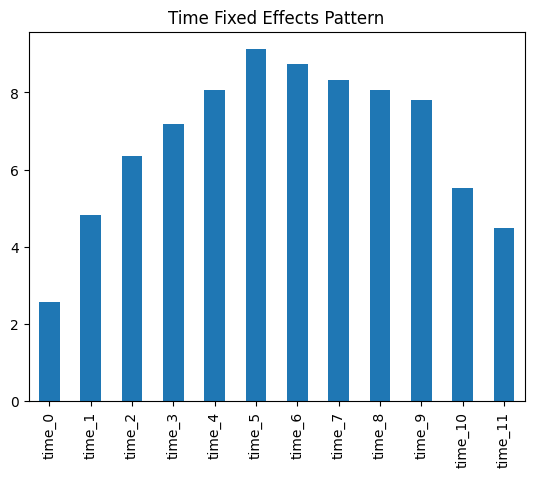

In [ ]:
# 1. Create the dummy variables for time (0 through 11)
# dropping_first=False keeps all time categories to see the raw constant for each
df_dummies = pd.get_dummies(df, columns=['time'], drop_first=False, dtype=int)

# 2. Define your predictors (the time dummies) and target variable
# Replace 'time_0', 'time_1', etc. automatically by filtering column names
time_cols = [col for col in df_dummies.columns if col.startswith('time_')]
X = df_dummies[time_cols]
y = df_dummies['y']

# 3. Fit the OLS regression model without an overarching intercept
# This forces the model to assign the full group constant to each time dummy
model = sm.OLS(y, X).fit()

# 4. Extract and print the fixed effect coefficients
fixed_effects = model.params
print(fixed_effects)

# 5. Optional: Plot to visually confirm Option A (inverted U-shape)
fixed_effects.plot(kind='bar', title='Time Fixed Effects Pattern')


A. Increase then decrease

## Question 2

What about the fixed effect for each city (0 through 9)? 

Option A
The effects gradually increase from city 0 to 9.

Option B
The effects increase from city 0 to about 4 or 5 but then eventually decrease again.

Option C
The effects vary randomly.

Option D
The effects decrease from city 0 to about 4 or 5 but then eventually increase again.

city_0    10.871199
city_1     5.315071
city_2     7.929660
city_3    12.874989
city_4    10.636539
city_5    -0.147974
city_6     7.979322
city_7     3.192338
city_8     3.369064
city_9     5.534343
dtype: float64


<Axes: title={'center': 'City Fixed Effects Pattern'}>

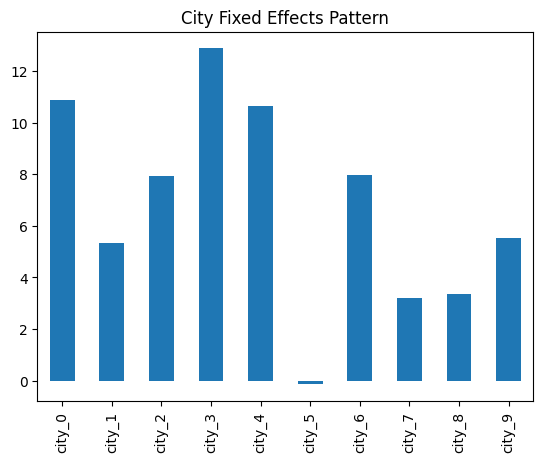

In [14]:
# 1. Create the dummy variables for time (0 through 11)
# dropping_first=False keeps all time categories to see the raw constant for each
df_dummies = pd.get_dummies(df, columns=['city'], drop_first=False, dtype=int)

# 2. Define your predictors (the time dummies) and target variable
# Replace 'time_0', 'time_1', etc. automatically by filtering column names
time_cols = [col for col in df_dummies.columns if col.startswith('city_')]
X = df_dummies[time_cols]
y = df_dummies['y']

# 3. Fit the OLS regression model without an overarching intercept
# This forces the model to assign the full group constant to each city dummy
model = sm.OLS(y, X).fit()

# 4. Extract and print the fixed effect coefficients
fixed_effects = model.params
print(fixed_effects)

# 5. Optional: Plot to visually confirm Option A (inverted U-shape)
fixed_effects.plot(kind='bar', title='City Fixed Effects Pattern')


C. Random

## Question 3

For the following data, model np.exp(Y) as a function of X and Z. 
```
num = 10000 
 
X = np.clip(np.random.normal(3, 1, (num,)), 0.01, 100)
Z = np.clip(np.random.normal(3, 1, (num,)), 0.01, 100)
Y = np.log(X + Z) + np.random.normal(0, 1, (num,)) 
```

With enough data, the coefficients of X and Z are closest to: 

Option A
Both 1.3 

Option B
Both 2.5

Option C
Both 1 

Option D
Both 1.6

## Question 4

Suppose we were to use the data below to find the standard error of X's coefficient (the coefficient that should be 1.5) in two ways: 
1)  By asking Python to find the standard error. 
2)  By simulating what happens if we generate the data 100 times, estimating X's coefficient and finding the standard deviation of the 100 estimates, using this model: 
```
     num = 10000 
     Z = np.random.normal(0, 1, (num,)) 
     X = Z + np.random.normal(0, 1, (num,)) 
     Y = 1.5 * X + 2.3 * Z + np.random.normal(0, X**2, (num,)) 
```
  
 Then:

Option A
One or both of them are zero.

Option B
 1) is significantly bigger than 2), but neither is zero. 

Option C
They are about the same. 

Option D
2) is significantly bigger than 1), but neither is zero.